<a href="https://colab.research.google.com/github/Harshitha-hunny/part2/blob/main/rfm_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
order=pd.read_csv('/content/drive/MyDrive/T2_Project_harshitha /d2c churn data package/orders.csv')

In [33]:
order['order_date']=pd.to_datetime(order['order_date'])
cutoff_date = pd.to_datetime('2025-09-30')
order = order[order['order_date'] <= cutoff_date]
print(order.shape)

(8137, 10)


In [34]:
order.head(10)

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0
5,ORD000003,CUST00001,2025-06-15,Hair Care,1,362.73,0.23,1,0,3.0
6,ORD000007,CUST00002,2025-08-21,Makeup,1,581.00,0.23,5,0,4.0
9,ORD000008,CUST00003,2025-04-12,Baby Care,2,649.98,0.47,2,0,2.0
10,ORD000009,CUST00004,2025-05-22,Skin Care,3,1604.04,0.16,5,0,2.0
11,ORD000013,CUST00005,2025-04-01,Hair Care,2,769.01,0.33,3,0,5.0


Build RFM features using the order data:

recency,
frequency,
monetary value.


In [35]:

latest_order_date = order['order_date'].max()
reference_date = latest_order_date + pd.Timedelta(days=1)

rfm= order.groupby('customer_id').agg(
    Recency=('order_date', lambda date: (reference_date - date.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('gross_amount', 'sum')
).reset_index()

print(rfm.head())

  customer_id  Recency  Frequency  Monetary
0   CUST00001      108          6   2955.57
1   CUST00002       41          1    581.00
2   CUST00003      172          1    649.98
3   CUST00004      132          1   1604.04
4   CUST00005       39          4   2550.91


Create at least five customer segments

In [36]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'], index=rfm.index)

rfm_df = pd.concat([rfm, rfm_scaled_df], axis=1)
print(rfm.head())

  customer_id  Recency  Frequency  Monetary
0   CUST00001      108          6   2955.57
1   CUST00002       41          1    581.00
2   CUST00003      172          1    649.98
3   CUST00004      132          1   1604.04
4   CUST00005       39          4   2550.91


In [37]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled_df)
rfm_df.head()


,customer_id,Recency,Frequency,Monetary,Recency_scaled,Frequency_scaled,Monetary_scaled,Cluster
0,CUST00001,108,6,2955.57,0.244932,1.095150,0.190690,0
1,CUST00002,41,1,581.00,-0.591305,-1.003174,-0.924833,2
2,CUST00003,172,1,649.98,1.043726,-1.003174,-0.892428,1
3,CUST00004,132,1,1604.04,0.544480,-1.003174,-0.444230,1
4,CUST00005,39,4,2550.91,-0.616268,0.255821,0.000589,0


In [38]:
count=rfm_df['Cluster'].value_counts().sort_index()
print(count)

Cluster
0    683
1    425
2    805
3    296
4    191
Name: count, dtype: int64


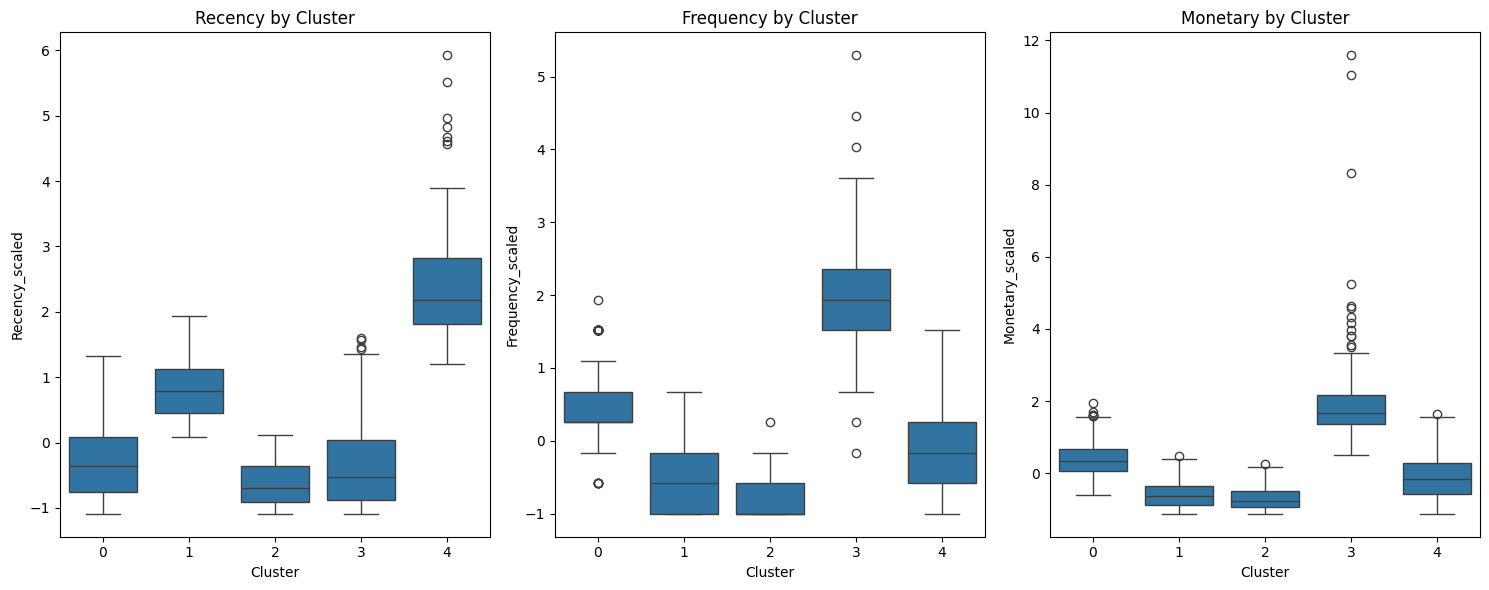

In [39]:
fig = plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
sns.boxplot(x='Cluster', y='Recency_scaled', data=rfm_df)
plt.title('Recency by Cluster')

plt.subplot(1, 3, 2)
sns.boxplot(x='Cluster', y='Frequency_scaled', data=rfm_df)
plt.title('Frequency by Cluster')

plt.subplot(1, 3, 3)
sns.boxplot(x='Cluster', y='Monetary_scaled', data=rfm_df)
plt.title('Monetary by Cluster')

plt.tight_layout()
plt.show()

Based on the cluster profiles

• Cluster 4 (at-risk customers): High Recency (haven't purchased in a long time), medium Frequency and Monetary.

• Cluster  3(Big Spenders/champions ): Low Recency, high Frequency, and very high Monetary. They don't buy as often as loyal customers but spend a lot when they do.

• Cluster 2 (New Customers): low Recency(most recent purchases), low Frequency and low Monetary. These could be new customers or those at risk of churning.

• Cluster 1 (dormant customers): mid-high Recency ,low-mid Frequency, and low Monetary.

• Cluster 0 (Loyal Customers): low-mid Recency, mid Frequency, and mid Monetary. These customers buy often and spend a good amount.





###Combine RFM with at least two additional non-RFM signals

In [40]:
# Calculate Discount amount
order['discount_amount'] = order['discount_pct'] * order['gross_amount']
discount_amount = order.groupby('customer_id')['discount_amount'].sum().reset_index()

# Calculate Category Diversity or number of category
category = order.groupby('customer_id')['category'].nunique().reset_index()

# combing both the features with rfm_df
rfm_df = pd.merge(rfm_df, discount_amount, on='customer_id', how='left')
rfm_df = pd.merge(rfm_df, category, on='customer_id', how='left')
rfm_df['discount_amount'] = rfm_df['discount_amount'].fillna(0)
rfm_df['category'] = rfm_df['category'].fillna(0)

print(rfm_df.head())

  customer_id  Recency  Frequency  Monetary  Recency_scaled  Frequency_scaled  \
0   CUST00001      108          6   2955.57        0.244932          1.095150   
1   CUST00002       41          1    581.00       -0.591305         -1.003174   
2   CUST00003      172          1    649.98        1.043726         -1.003174   
3   CUST00004      132          1   1604.04        0.544480         -1.003174   
4   CUST00005       39          4   2550.91       -0.616268          0.255821   

   Monetary_scaled  Cluster  discount_amount  category  
0         0.190690        0        1082.9973         3  
1        -0.924833        2         133.6300         1  
2        -0.892428        1         305.4906         1  
3        -0.444230        1         256.6464         1  
4         0.000589        0        1102.1179         2  


In [41]:
features = ['Recency', 'Frequency', 'Monetary', 'discount_amount', 'category']

#scaling
new_rfm = scaler.fit_transform(rfm_df[features])
new_rfm_df = pd.DataFrame(new_rfm, columns=[f'{col}_scaled' for col in features], index=rfm_df.index)

# Drop old scaled RFM columns
rfm_df = rfm_df.drop(columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'], errors='ignore')
rfm_df = pd.concat([rfm_df, new_rfm_df], axis=1)

#clustering
rfm_df['new_Cluster'] = kmeans.fit_predict(new_rfm_df)

print(rfm_df.head())

  customer_id  Recency  Frequency  Monetary  Cluster  discount_amount  \
0   CUST00001      108          6   2955.57        0        1082.9973   
1   CUST00002       41          1    581.00        2         133.6300   
2   CUST00003      172          1    649.98        1         305.4906   
3   CUST00004      132          1   1604.04        1         256.6464   
4   CUST00005       39          4   2550.91        0        1102.1179   

   category  Recency_scaled  Frequency_scaled  Monetary_scaled  \
0         3        0.244932          1.095150         0.190690   
1         1       -0.591305         -1.003174        -0.924833   
2         1        1.043726         -1.003174        -0.892428   
3         1        0.544480         -1.003174        -0.444230   
4         2       -0.616268          0.255821         0.000589   

   discount_amount_scaled  category_scaled  new_Cluster  
0                0.748684         0.514837            4  
1               -0.921892        -1.072328      


New Cluster Profiles

             Recency_scaled  Frequency_scaled  Monetary_scaled  \
new_Cluster                                                      
0                  1.735933         -0.476361        -0.426993   
1                 -0.405624          2.325091         2.413446   
2                 -0.431254         -0.842671        -0.745814   
3                 -0.286733          0.167936         0.065363   
4                 -0.129148          1.167575         1.050138   

             discount_amount_scaled  category_scaled  
new_Cluster                                           
0                         -0.433913        -0.407492  
1                          2.556158         1.662479  
2                         -0.718748        -0.891336  
3                          0.049727         0.330612  
4                          0.980494         1.171465  


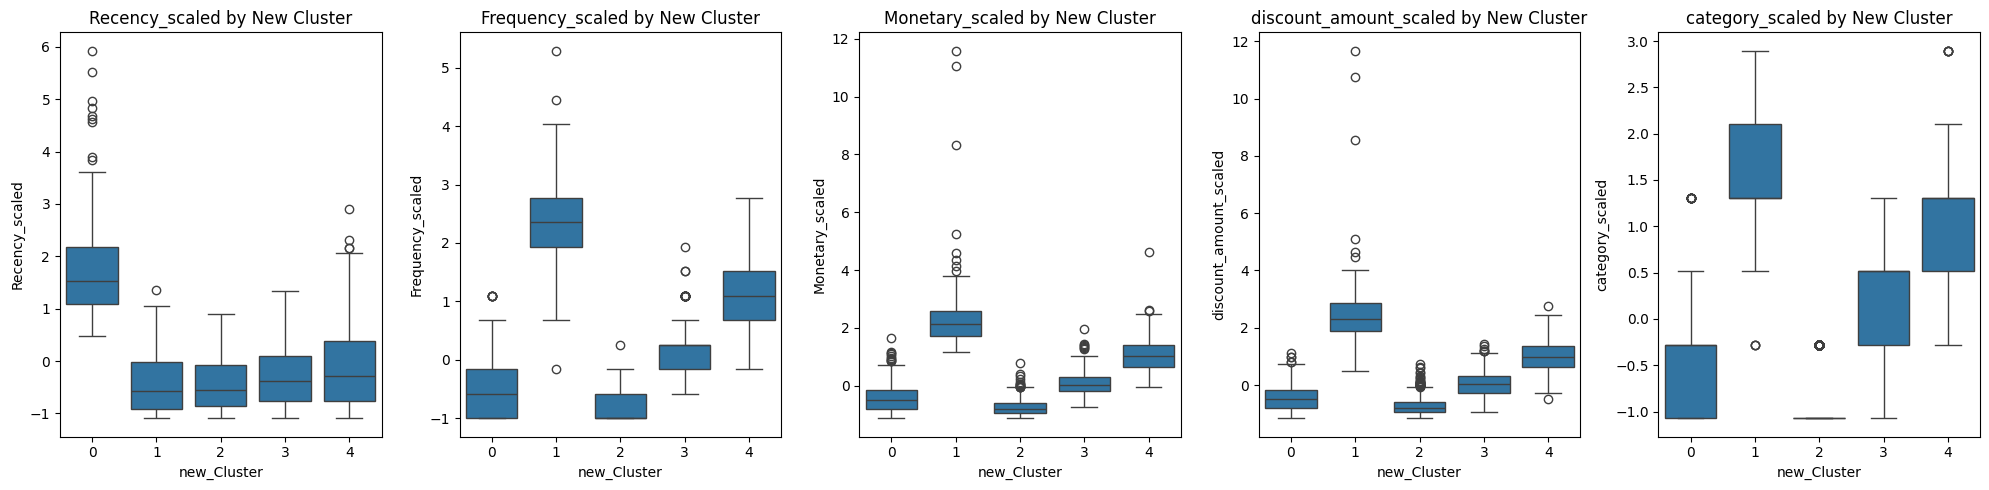

In [42]:
new_features = [f'{col}_scaled' for col in features]
new_cluster_profiles = rfm_df.groupby('new_Cluster')[new_features].mean()

print("\nNew Cluster Profiles\n")
print(new_cluster_profiles)

fig, axes = plt.subplots(ncols=len(new_features), figsize=(4 * len(features), 5))
for i, col in enumerate(new_features):
    sns.boxplot(x='new_Cluster', y=col, data=rfm_df, ax=axes[i])
    axes[i].set_title(f'{col} by New Cluster')
plt.tight_layout()
plt.show()

Based on the enriched cluster profiles, we can now assign new meaningful names to each segment and recommend retention actions:

*   **Cluster 0 (At-Risk/dormant Segment):**
    *   **Characteristics:** High Recency (haven't purchased recently), low Frequency, low Monetary, low Discount amount Usage, moderate Category Diversity. These customers are drifting away.
    *   **Retention Action:** Re-engagement campaigns with personalized offers, notify them about new products in categories they previously showed interest in. Offer providing for their next purchase.

*   **Cluster 1 (Discount-Sensitive customers):**
    *   **Characteristics:** low-Moderate Recency, high Frequency,very high Monetary,very high Discount Usage,very high Category Diversity. These customers are valuable but respond well to discounts and explore various categories.
    *   **Retention Action:**VIP programs, exclusive product launches, early access to new collections, personalized thank-you notes, and gathering feedback for product improvement.

*   **Cluster 2 (New/churn customers):**
    *   **Characteristics:** low Recency, very low Frequency, very low Monetary, very low Discount Usage, very low Category Diversity. These could be new customers who haven't made a second purchase or those who have churned completely.
    *   **Retention Action:**  notify them about new products and discounts for new customers , surveys to understand reasons for inactivity, offers with significant (welcome back/first-purchase) discounts for inactive/new customers.

*   **Cluster 3 (loyal customers):**
    *   **Characteristics:** Low Recency , medium- high Frequency, moderate Monetary, moderate Discount Usage, moderate- high Category Diversity. These are your best, most engaged customers who buy often and spend a lot across many categories, often without needing deep discounts.
    *   **Retention Action:**
     Exclusive early access to sales, loyalty programs linked with discounts, and personalized recommendations for new products.
.

*   **Cluster 4 (Potential Big Spenders):**
    *   **Characteristics:** moderate-high Recency, moderate Frequency, high Monetary, moderate Discount Usage, high Category Diversity. These customers spend a good amount and explore categories but don't purchase as frequently as champions. They might be influenced by discounts.
    *   **Retention Action:** Targeted campaigns for complementary products, bundle offers, and reminders about upcoming sales that align with their past purchase , gathering feedback for product improvement.

In [43]:
segment = {
    0: 'At-Risk/dormant Segment',
    1: 'Discount-Sensitive customers',
    2: 'New/churn customers',
    3: 'loyal customers',
    4: 'Potential Big Spenders'
}

rfm_df['segment'] = rfm_df['new_Cluster'].map(segment)

print(rfm_df.head())

  customer_id  Recency  Frequency  Monetary  Cluster  discount_amount  \
0   CUST00001      108          6   2955.57        0        1082.9973   
1   CUST00002       41          1    581.00        2         133.6300   
2   CUST00003      172          1    649.98        1         305.4906   
3   CUST00004      132          1   1604.04        1         256.6464   
4   CUST00005       39          4   2550.91        0        1102.1179   

   category  Recency_scaled  Frequency_scaled  Monetary_scaled  \
0         3        0.244932          1.095150         0.190690   
1         1       -0.591305         -1.003174        -0.924833   
2         1        1.043726         -1.003174        -0.892428   
3         1        0.544480         -1.003174        -0.444230   
4         2       -0.616268          0.255821         0.000589   

   discount_amount_scaled  category_scaled  new_Cluster  \
0                0.748684         0.514837            4   
1               -0.921892        -1.072328    

In [44]:
rfm_df.to_csv('segement.csv', index=False)
